# 📊 Student Performance Analysis  
### Task 1 – Data Science / Data Analysis with Python Internship

---

## 📌 Overview
This notebook presents an exploratory data analysis of the **Student Performance Dataset**.
The objective of this task is to apply the complete data science workflow:

**Load → Clean → Analyze → Visualize → Conclude**

The analysis focuses on understanding student academic performance and identifying
key factors that influence final grades.

---

## 🎯 Objectives
- Load and clean the student performance dataset
- Perform exploratory data analysis using Python
- Answer key analytical questions related to student performance
- Visualize insights using appropriate charts
- Document findings clearly using Markdown

---

## 🛠 Tools & Technologies
- Python  
- Pandas  
- Matplotlib  
- Jupyter Notebook / Google Colab  

---

## 📂 Dataset
- **Source**: UCI Machine Learning Repository  
- **Dataset**: Student Performance (student-mat.csv)  
- **Target Variable**: Final Grade (G3)

---

## ✅ Task Status
✔ Task 1 Completed  
✔ Fully documented and reproducible analysis


# 1. Load Dataset

## Dataset Download (UCI Repository)

The dataset is sourced from the **UCI Machine Learning Repository**.
If the dataset file is not found locally, it is automatically downloaded
and extracted using shell commands (supported in Google Colab).


In [42]:
import os
import pandas as pd

# Check if dataset already exists
if not os.path.exists("student-mat.csv"):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip
    !unzip student.zip

Now import required python libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We are going to use pandas to load CSV file

as The file uses a semicolon (;) as the delimiter we are gonna use sep=";" in read_csv

In [18]:
std_df=pd.read_csv("student-mat.csv",sep=";")

In [20]:
std_df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


# 2. Explore & Clean Data

We inspect the dataset to understand its structure, size, and data types.

In [21]:
std_df.shape

(395, 33)

In [22]:
std_df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


We check for missing values and remove duplicate records to ensure data quality.

1) Check Missing Values

In [25]:
print(std_df.isnull().sum())
print(f"total null values:{std_df.isnull().sum().sum()}")


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
total null values:0


2) Remove Duplicate Records

In [26]:
std_df.drop_duplicates()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


# 3. Analysis Questions

## 1) Average final grade (G3).

We calculate the mean of the final grades.

In [11]:
print((std_df['G3']).mean().round(3))

10.415


The average final grade of all student is **10.415**

## 2) How many students scored above 15?

We count how many students scored more than 15 in the final exam

In [10]:
num=(std_df['G3']>15).sum()
print(num)

40


There are **40** students who scored more than 15 in final exam

## 3) Is study time correlated with performance?

We compute the Pearson correlation coefficient between study time and final grade.

In [27]:
correlation=std_df['studytime'].corr(std_df['G3'])
correlation.round(3)

np.float64(0.098)

**Interpretation:**

There is a weak positive correlation (**+0.098**) between study time and academic performance, indicating that increased study time slightly improves grades, though other factors also influence performance.

## 4) Which gender performs better on average?

In [ ]:
std_df.groupby('sex')['G3'].mean()

,G3
sex,
F,9.966346
M,10.914439


We can see that average finale score of boys is **10.91** and average score of girls is **9.97**

hence boys perform slightly better in exam


---


---





# 4. Visualizations

* Histogram of grades.

This histogram shows the distribution of students' final grades.

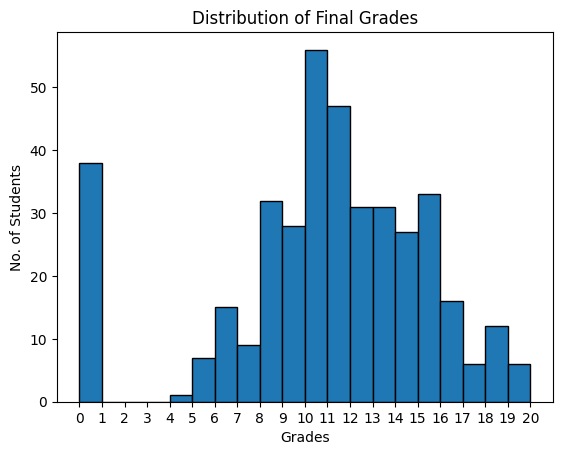

In [36]:
plt.figure()
data=std_df['G3']
plt.hist(data,bins=20,edgecolor='black')
plt.xticks(np.arange(0,21,step=1))
plt.xlabel("Grades")
plt.ylabel("No. of Students")
plt.title("Distribution of Final Grades")
plt.show()



---



---


* Scatterplot: study time vs grades.




This scatter plot visualizes the relationship between study time and academic performance.

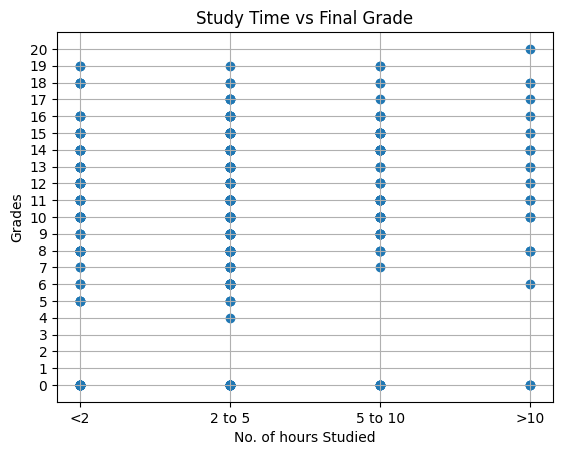

In [37]:
plt.figure()
plt.scatter(std_df['studytime'],std_df['G3'])
plt.xticks([1,2,3,4],["<2","2 to 5","5 to 10",">10"])
plt.xlabel("No. of hours Studied")
plt.yticks(np.arange(0,21,step=1))
plt.ylabel("Grades")
plt.title("Study Time vs Final Grade")
plt.grid(True)
plt.show()



---



---


* Bar chart: male vs female average score.

This bar chart compares the average final grades of male and female students.

In [30]:
df=std_df.groupby('sex')['G3'].mean()
df

,G3
sex,
F,9.966346
M,10.914439


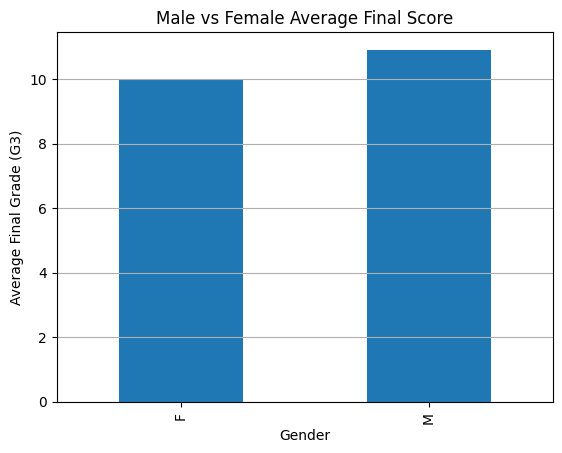

In [41]:
plt.figure()
df.plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")
plt.title("Male vs Female Average Final Score")
plt.title("Male vs Female Average Final Score")
plt.grid(axis="y")
plt.show()


# Conclusion



*   The average final grade indicates moderate overall student performance.
*   Only a limited number of students (40 out of 395 students) scored above 15.
* Study time shows a weak positive correlation (+0.098) with final grades.
* Gender-based differences in academic performance are minimal.
* Student performance is influenced by multiple academic and personal factors.





